# PROYECTO: Mantenimiento Predictivo — Línea de Manufactura
# Dataset: AI4I 2020 Predictive Maintenance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid", palette="muted")

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('/content/ai4i2020.csv')
print(f"✅ Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")

Saving ai4i2020.csv to ai4i2020 (1).csv
✅ Dataset cargado: 10000 filas x 14 columnas


In [4]:
print("=" * 55)
print("INSPECCIÓN INICIAL DEL DATASET")
print("=" * 55)

print("\n--- Primeras 5 filas ---")
display(df.head())

print("\n--- Tipos de datos y valores nulos ---")
info = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos': df.nunique()
})
display(info)

print("\n--- Estadísticas descriptivas ---")
display(df.describe().round(2))

INSPECCIÓN INICIAL DEL DATASET

--- Primeras 5 filas ---


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



--- Tipos de datos y valores nulos ---


,Tipo,Nulos,% Nulos,Únicos
UDI,int64,0,0.0,10000
Product ID,object,0,0.0,10000
Type,object,0,0.0,3
Air temperature [K],float64,0,0.0,93
Process temperature [K],float64,0,0.0,82
Rotational speed [rpm],int64,0,0.0,941
Torque [Nm],float64,0,0.0,577
Tool wear [min],int64,0,0.0,246
Machine failure,int64,0,0.0,2
TWF,int64,0,0.0,2



--- Estadísticas descriptivas ---


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,300.0,310.01,1538.78,39.99,107.95,0.03,0.00,0.01,0.01,0.01,0.00
std,2886.90,2.0,1.48,179.28,9.97,63.65,0.18,0.07,0.11,0.10,0.10,0.04
min,1.00,295.3,305.70,1168.00,3.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2500.75,298.3,308.80,1423.00,33.20,53.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,5000.50,300.1,310.10,1503.00,40.10,108.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,7500.25,301.5,311.10,1612.00,46.80,162.00,0.00,0.00,0.00,0.00,0.00,0.00
max,10000.00,304.5,313.80,2886.00,76.60,253.00,1.00,1.00,1.00,1.00,1.00,1.00


DISTRIBUCIÓN DE FALLAS (Variable objetivo)


,Cantidad,Porcentaje
Sin falla (0),9661,96.61
Con falla (1),339,3.39


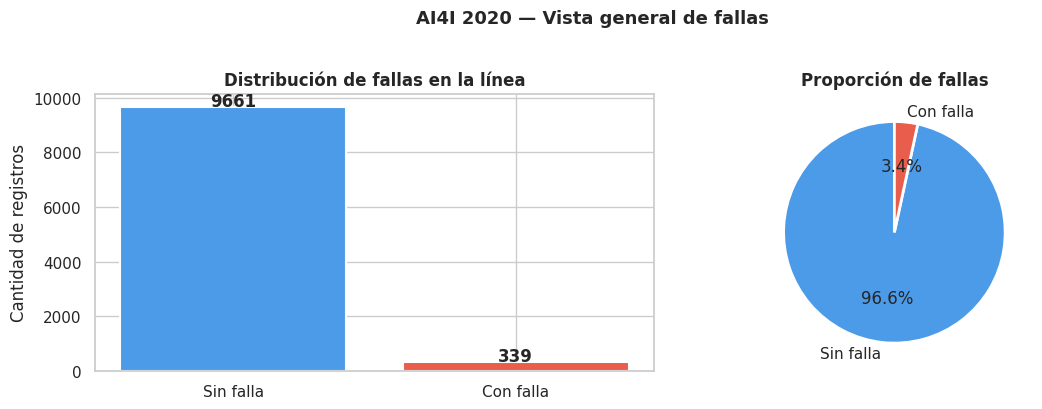

✅ Gráfico guardado como 01_distribucion_fallas.png


In [5]:
print("=" * 55)
print("DISTRIBUCIÓN DE FALLAS (Variable objetivo)")
print("=" * 55)

fallas = df['Machine failure'].value_counts()
pct = df['Machine failure'].value_counts(normalize=True) * 100

resumen = pd.DataFrame({
    'Cantidad': fallas,
    'Porcentaje': pct.round(2)
})
resumen.index = ['Sin falla (0)', 'Con falla (1)']
display(resumen)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Sin falla', 'Con falla'], fallas.values,
            color=['#4C9BE8', '#E85D4C'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de fallas en la línea', fontweight='bold')
axes[0].set_ylabel('Cantidad de registros')
for i, v in enumerate(fallas.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(fallas.values, labels=['Sin falla', 'Con falla'],
            colors=['#4C9BE8', '#E85D4C'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de fallas', fontweight='bold')

plt.suptitle('AI4I 2020 — Vista general de fallas', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_distribucion_fallas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado como 01_distribucion_fallas.png")

# Análisis Exploratorio de Datos (EDA)

In [6]:
df.columns = [
    'UDI', 'product_id', 'type', 'air_temp', 'process_temp',
    'rot_speed', 'torque', 'tool_wear', 'failure',
    'TWF', 'HDF', 'PWF', 'OSF', 'RNF'
]

print("✅ Columnas renombradas:")
print(df.columns.tolist())

✅ Columnas renombradas:
['UDI', 'product_id', 'type', 'air_temp', 'process_temp', 'rot_speed', 'torque', 'tool_wear', 'failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


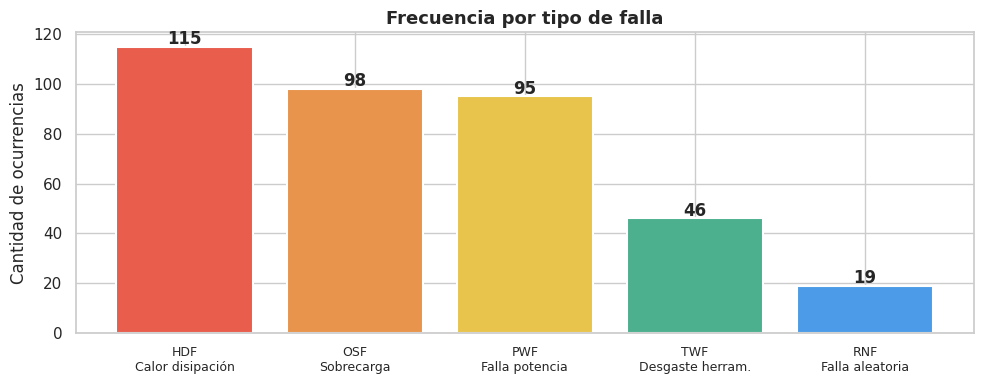

In [7]:
# Tipos de falla y su frecuencia
tipos_falla = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
conteos = df[tipos_falla].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(conteos.index, conteos.values,
              color=['#E85D4C','#E8944C','#E8C44C','#4CAF8E','#4C9BE8'],
              edgecolor='white', linewidth=1.5)
ax.set_title('Frecuencia por tipo de falla', fontweight='bold', fontsize=13)
ax.set_ylabel('Cantidad de ocurrencias')
for bar, val in zip(bars, conteos.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontweight='bold')

# Etiquetas descriptivas
labels = {
    'HDF': 'HDF\nCalor disipación',
    'PWF': 'PWF\nFalla potencia',
    'OSF': 'OSF\nSobrecarga',
    'TWF': 'TWF\nDesgaste herram.',
    'RNF': 'RNF\nFalla aleatoria'
}
ax.set_xticklabels([labels[t] for t in conteos.index], fontsize=9)
plt.tight_layout()
plt.savefig('02_tipos_falla.png', dpi=150, bbox_inches='tight')
plt.show()

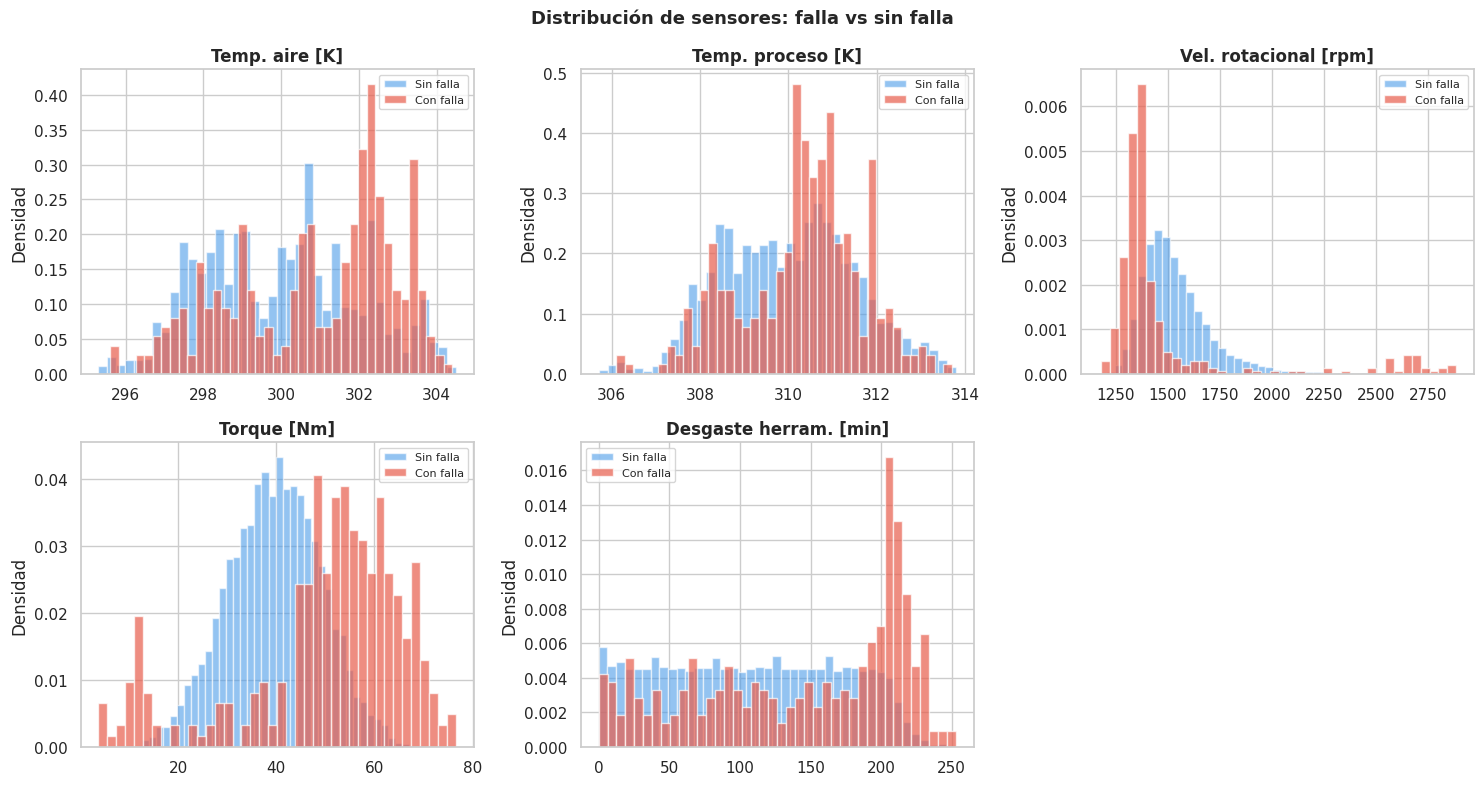

In [9]:
# Distribución de cada sensor por estado (falla vs no falla)
sensores = ['air_temp', 'process_temp', 'rot_speed', 'torque', 'tool_wear']
nombres = ['Temp. aire [K]', 'Temp. proceso [K]',
           'Vel. rotacional [rpm]', 'Torque [Nm]', 'Desgaste herram. [min]']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, nombre) in enumerate(zip(sensores, nombres)):
    sin_falla = df[df['failure'] == 0][col]
    con_falla = df[df['failure'] == 1][col]

    axes[i].hist(sin_falla, bins=40, alpha=0.6, color='#4C9BE8', label='Sin falla', density=True)
    axes[i].hist(con_falla, bins=40, alpha=0.7, color='#E85D4C', label='Con falla', density=True)
    axes[i].set_title(nombre, fontweight='bold')
    axes[i].set_ylabel('Densidad')
    axes[i].legend(fontsize=8)

axes[5].axis('off')
plt.suptitle('Distribución de sensores: falla vs sin falla', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_distribucion_sensores.png', dpi=150, bbox_inches='tight')
plt.show()

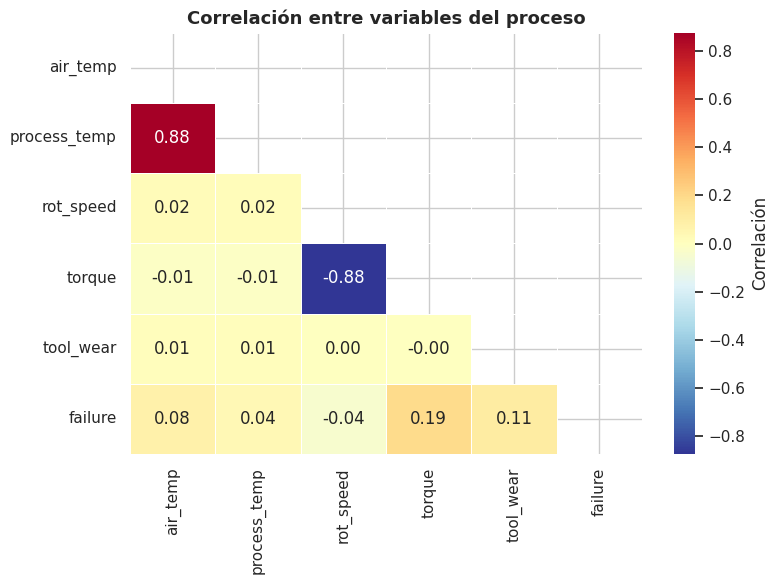

In [10]:
# Mapa de correlación
cols_numericas = ['air_temp', 'process_temp', 'rot_speed', 'torque', 'tool_wear', 'failure']
corr = df[cols_numericas].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Correlación'})
ax.set_title('Correlación entre variables del proceso', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('04_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

TASA DE FALLA POR TIPO DE PRODUCTO


,Fallas,Total,Tasa,Tasa %
Alta calidad (H),21,1003,0.020937,2.09
Baja calidad (L),235,6000,0.039167,3.92
Media calidad (M),83,2997,0.027694,2.77


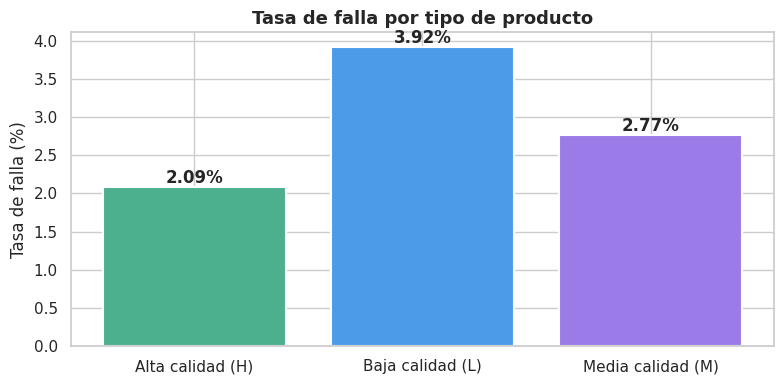

In [11]:
# Tasa de falla según tipo de producto (L = Low, M = Medium, H = High quality)
falla_por_tipo = df.groupby('type')['failure'].agg(['sum', 'count', 'mean'])
falla_por_tipo.columns = ['Fallas', 'Total', 'Tasa']
falla_por_tipo['Tasa %'] = (falla_por_tipo['Tasa'] * 100).round(2)
falla_por_tipo.index = ['Alta calidad (H)', 'Baja calidad (L)', 'Media calidad (M)']

print("=" * 45)
print("TASA DE FALLA POR TIPO DE PRODUCTO")
print("=" * 45)
display(falla_por_tipo)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4CAF8E', '#4C9BE8', '#9B7BE8']
bars = ax.bar(falla_por_tipo.index, falla_por_tipo['Tasa %'],
              color=colors, edgecolor='white', linewidth=1.5)
ax.set_title('Tasa de falla por tipo de producto', fontweight='bold', fontsize=13)
ax.set_ylabel('Tasa de falla (%)')
for bar, val in zip(bars, falla_por_tipo['Tasa %']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('05_falla_por_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

# INGENIERÍA DE FEATURES

In [12]:
df_model = df.copy()

# Feature 1: Diferencia de temperaturas
# La física del HDF dice que si (process_temp - air_temp) es muy alto,
# el sistema no está disipando calor correctamente
df_model['temp_diff'] = df_model['process_temp'] - df_model['air_temp']

# Feature 2: Potencia mecánica (torque × velocidad angular)
# Identifica condiciones de sobrecarga — relacionado con PWF y OSF
df_model['power'] = df_model['torque'] * df_model['rot_speed']

# Feature 3: Estrés mecánico (torque / velocidad)
# Alta cuando la máquina trabaja lento bajo carga — señal de desgaste
df_model['mech_stress'] = df_model['torque'] / (df_model['rot_speed'] + 1)

# Feature 4: Desgaste acumulado × torque
# Combina dos señales de deterioro — herramienta gastada bajo alta carga
df_model['wear_torque'] = df_model['tool_wear'] * df_model['torque']

# Feature 5: Codificar el tipo de producto
df_model['type_encoded'] = df_model['type'].map({'L': 0, 'M': 1, 'H': 2})

# Verificación
nuevos_features = ['temp_diff', 'power', 'mech_stress', 'wear_torque', 'type_encoded']
print("✅ Features creados:")
display(df_model[nuevos_features + ['failure']].describe().round(3))

✅ Features creados:


,temp_diff,power,mech_stress,wear_torque,type_encoded,failure
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,10.001,59967.147,0.027,4314.665,0.500,0.034
std,1.001,10193.094,0.009,2826.568,0.671,0.181
min,7.600,10966.800,0.001,0.000,0.000,0.000
25%,9.300,53105.400,0.021,1963.650,0.000,0.000
50%,9.800,59883.900,0.027,4012.950,0.000,0.000
75%,11.000,66873.750,0.033,6279.000,1.000,0.000
max,12.100,99980.400,0.064,16497.000,2.000,1.000


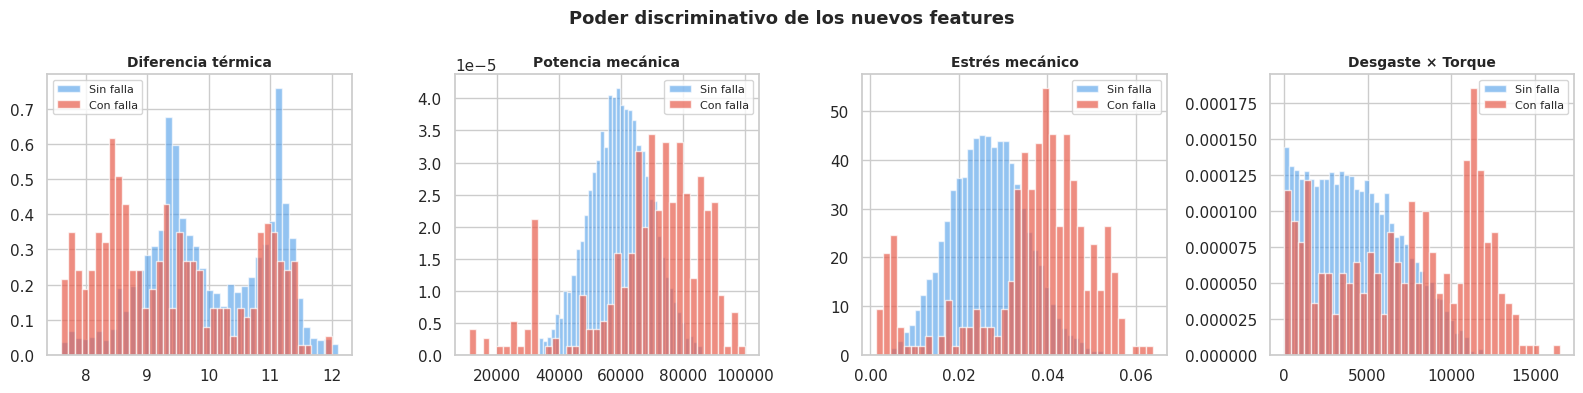

In [13]:
# Comparar los nuevos features entre máquinas con y sin falla
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

features_nuevos = ['temp_diff', 'power', 'mech_stress', 'wear_torque']
nombres_nuevos = ['Diferencia térmica', 'Potencia mecánica',
                  'Estrés mecánico', 'Desgaste × Torque']

for i, (feat, nombre) in enumerate(zip(features_nuevos, nombres_nuevos)):
    sin = df_model[df_model['failure'] == 0][feat]
    con = df_model[df_model['failure'] == 1][feat]
    axes[i].hist(sin, bins=40, alpha=0.6, color='#4C9BE8', label='Sin falla', density=True)
    axes[i].hist(con, bins=40, alpha=0.7, color='#E85D4C', label='Con falla', density=True)
    axes[i].set_title(nombre, fontweight='bold', fontsize=10)
    axes[i].legend(fontsize=8)

plt.suptitle('Poder discriminativo de los nuevos features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_nuevos_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Definir features finales y variable objetivo
FEATURES = [
    'air_temp', 'process_temp', 'rot_speed', 'torque', 'tool_wear',
    'temp_diff', 'power', 'mech_stress', 'wear_torque', 'type_encoded'
]
TARGET = 'failure'

X = df_model[FEATURES]
y = df_model[TARGET]

# División train/test — 80% entrenamiento, 20% prueba
# stratify=y garantiza que ambos conjuntos tengan la misma proporción de fallas
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar los features (necesario para algunos modelos)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)  # Ojo: solo transform, nunca fit en test

print("=" * 45)
print("RESUMEN DE LA PARTICIÓN")
print("=" * 45)
print(f"Entrenamiento : {X_train.shape[0]:,} registros")
print(f"Prueba        : {X_test.shape[0]:,} registros")
print(f"\nFallas en entrenamiento : {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Fallas en prueba        : {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print("\n✅ Partición estratificada correcta")

RESUMEN DE LA PARTICIÓN
Entrenamiento : 8,000 registros
Prueba        : 2,000 registros

Fallas en entrenamiento : 271 (3.4%)
Fallas en prueba        : 68 (3.4%)

✅ Partición estratificada correcta


In [15]:
# SMOTE genera ejemplos sintéticos de la clase minoritaria (fallas)
# Es la técnica estándar en industria para este tipo de problema
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    !pip install imbalanced-learn -q
    from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

print("=" * 45)
print("ANTES Y DESPUÉS DE SMOTE")
print("=" * 45)
print(f"Antes  — Sin falla: {(y_train==0).sum():,} | Con falla: {(y_train==1).sum():,}")
print(f"Después — Sin falla: {(y_train_bal==0).sum():,} | Con falla: {(y_train_bal==1).sum():,}")
print("\n✅ Clases balanceadas para entrenamiento")

ANTES Y DESPUÉS DE SMOTE
Antes  — Sin falla: 7,729 | Con falla: 271
Después — Sin falla: 7,729 | Con falla: 7,729

✅ Clases balanceadas para entrenamiento


# ENTRENAMIENTO Y EVALUACIÓN DE MODELOS

In [16]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)
import time

modelos = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

resultados = {}

print("=" * 55)
print("ENTRENAMIENTO DE MODELOS")
print("=" * 55)

for nombre, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(X_train_bal, y_train_bal)
    tiempo = round(time.time() - inicio, 2)

    y_pred  = modelo.predict(X_test_sc)
    y_proba = modelo.predict_proba(X_test_sc)[:, 1]

    roc_auc = roc_auc_score(y_test, y_proba)
    ap      = average_precision_score(y_test, y_proba)

    resultados[nombre] = {
        'modelo':  modelo,
        'y_pred':  y_pred,
        'y_proba': y_proba,
        'roc_auc': roc_auc,
        'ap':      ap,
        'tiempo':  tiempo
    }
    print(f"\n{nombre}")
    print(f"  ROC-AUC : {roc_auc:.4f}  |  Avg Precision : {ap:.4f}  |  Tiempo: {tiempo}s")

print("\n✅ Modelos entrenados")

ENTRENAMIENTO DE MODELOS

Logistic Regression
  ROC-AUC : 0.9394  |  Avg Precision : 0.4169  |  Tiempo: 0.07s

Random Forest
  ROC-AUC : 0.9837  |  Avg Precision : 0.8496  |  Tiempo: 6.19s

Gradient Boosting
  ROC-AUC : 0.9786  |  Avg Precision : 0.8555  |  Tiempo: 12.82s

✅ Modelos entrenados


In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

filas = []
for nombre, r in resultados.items():
    filas.append({
        'Modelo':      nombre,
        'ROC-AUC':     round(r['roc_auc'], 4),
        'Avg Prec.':   round(r['ap'], 4),
        'Precision':   round(precision_score(y_test, r['y_pred']), 4),
        'Recall':      round(recall_score(y_test, r['y_pred']), 4),
        'F1-Score':    round(f1_score(y_test, r['y_pred']), 4),
        'Tiempo (s)':  r['tiempo']
    })

df_resultados = pd.DataFrame(filas).set_index('Modelo')
display(df_resultados)

# Identificar el mejor modelo por ROC-AUC
mejor_nombre = df_resultados['ROC-AUC'].idxmax()
print(f"\n🏆 Mejor modelo: {mejor_nombre} (ROC-AUC: {df_resultados.loc[mejor_nombre, 'ROC-AUC']})")

,ROC-AUC,Avg Prec.,Precision,Recall,F1-Score,Tiempo (s)
Modelo,,,,,,
Logistic Regression,0.9394,0.4169,0.1802,0.8824,0.2993,0.07
Random Forest,0.9837,0.8496,0.6129,0.8382,0.7081,6.19
Gradient Boosting,0.9786,0.8555,0.3910,0.8971,0.5446,12.82



🏆 Mejor modelo: Random Forest (ROC-AUC: 0.9837)


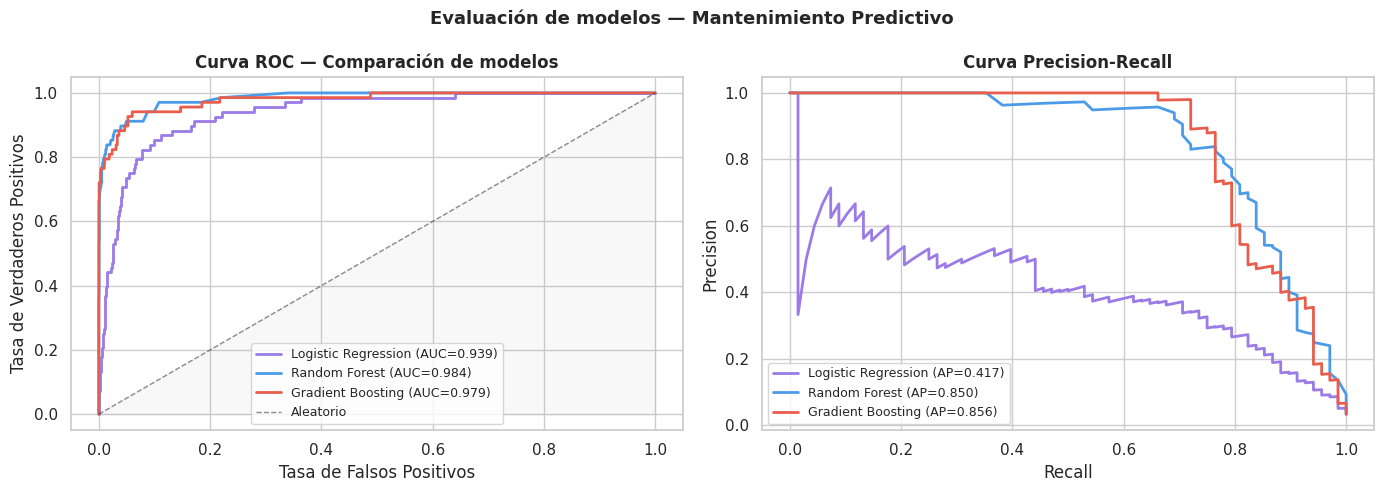

In [18]:
colores = ['#9B7BE8', '#4C9BE8', '#E85D4C']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
for (nombre, r), color in zip(resultados.items(), colores):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{nombre} (AUC={r['roc_auc']:.3f})")
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Aleatorio')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curva ROC — Comparación de modelos', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].fill_between([0,1],[0,1], alpha=0.05, color='gray')

# Curva Precision-Recall (más relevante con clases desbalanceadas)
for (nombre, r), color in zip(resultados.items(), colores):
    prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    axes[1].plot(rec, prec, color=color, linewidth=2,
                 label=f"{nombre} (AP={r['ap']:.3f})")
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Evaluación de modelos — Mantenimiento Predictivo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

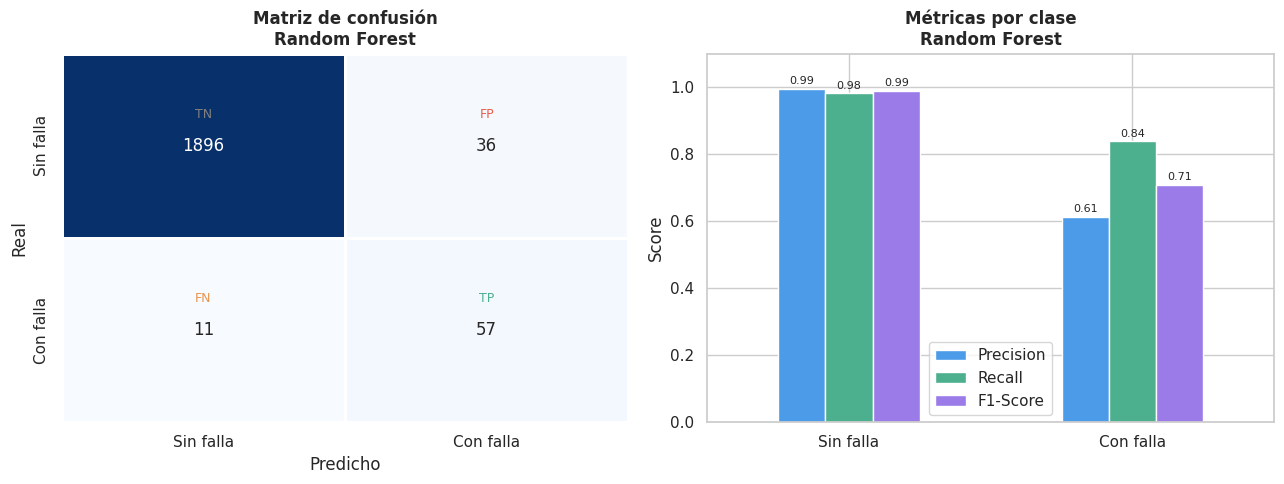


📊 Resumen del mejor modelo (Random Forest):
   Verdaderos Positivos (fallas detectadas) : 57
   Falsos Negativos (fallas no detectadas)  : 11  ← el más costoso
   Falsos Positivos (falsas alarmas)         : 36


In [19]:
mejor = resultados[mejor_nombre]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, mejor['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Sin falla', 'Con falla'],
            yticklabels=['Sin falla', 'Con falla'],
            linewidths=1, linecolor='white', cbar=False)
axes[0].set_title(f'Matriz de confusión\n{mejor_nombre}', fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Anotar las 4 celdas con etiquetas
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, 0.35, 'TN', color='gray', ha='center', fontsize=9)
axes[0].text(1.5, 0.35, 'FP', color='#E85D4C', ha='center', fontsize=9)
axes[0].text(0.5, 1.35, 'FN', color='#E8944C', ha='center', fontsize=9)
axes[0].text(1.5, 1.35, 'TP', color='#4CAF8E', ha='center', fontsize=9)

# Reporte de clasificación como gráfico de barras
reporte = classification_report(y_test, mejor['y_pred'],
                                target_names=['Sin falla','Con falla'],
                                output_dict=True)
metricas = pd.DataFrame(reporte).T.iloc[:2][['precision','recall','f1-score']]
metricas.plot(kind='bar', ax=axes[1], color=['#4C9BE8','#4CAF8E','#9B7BE8'],
              edgecolor='white', linewidth=1)
axes[1].set_title(f'Métricas por clase\n{mejor_nombre}', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_xticklabels(['Sin falla', 'Con falla'], rotation=0)
axes[1].legend(['Precision', 'Recall', 'F1-Score'])
axes[1].set_ylim(0, 1.1)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('08_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Resumen del mejor modelo ({mejor_nombre}):")
print(f"   Verdaderos Positivos (fallas detectadas) : {tp}")
print(f"   Falsos Negativos (fallas no detectadas)  : {fn}  ← el más costoso")
print(f"   Falsos Positivos (falsas alarmas)         : {fp}")

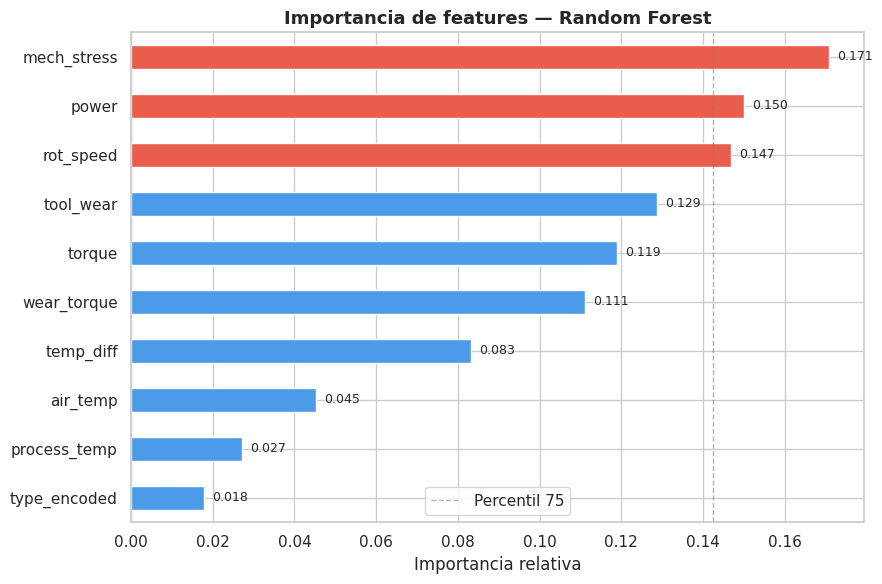

In [20]:
if mejor_nombre in ['Random Forest', 'Gradient Boosting']:
    importancias = pd.Series(
        mejor['modelo'].feature_importances_,
        index=FEATURES
    ).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, 6))
    colores_imp = ['#E85D4C' if v > importancias.quantile(0.75) else '#4C9BE8'
                   for v in importancias.values]
    importancias.plot(kind='barh', ax=ax, color=colores_imp, edgecolor='white')
    ax.set_title(f'Importancia de features — {mejor_nombre}', fontweight='bold', fontsize=13)
    ax.set_xlabel('Importancia relativa')
    ax.axvline(importancias.quantile(0.75), color='gray', linestyle='--',
               alpha=0.6, linewidth=1, label='Percentil 75')
    ax.legend()
    for i, v in enumerate(importancias.values):
        ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('09_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

# GUARDAR MODELO Y ARTEFACTOS FINALES

In [21]:
import joblib
import os

os.makedirs('modelo', exist_ok=True)

# Guardar modelo y scaler
joblib.dump(mejor['modelo'], 'modelo/random_forest_model.pkl')
joblib.dump(scaler,          'modelo/scaler.pkl')
joblib.dump(FEATURES,        'modelo/features.pkl')

print("✅ Modelo guardado en /modelo/")
print(f"   - random_forest_model.pkl")
print(f"   - scaler.pkl")
print(f"   - features.pkl")

✅ Modelo guardado en /modelo/
   - random_forest_model.pkl
   - scaler.pkl
   - features.pkl


In [22]:
def predecir_falla(air_temp, process_temp, rot_speed, torque, tool_wear, tipo):
    """
    Predice si una máquina está en riesgo de falla.

    Parámetros:
        air_temp     : Temperatura del aire [K]
        process_temp : Temperatura del proceso [K]
        rot_speed    : Velocidad rotacional [rpm]
        torque       : Torque [Nm]
        tool_wear    : Desgaste de herramienta [min]
        tipo         : Tipo de producto ('L', 'M', 'H')

    Retorna:
        dict con predicción, probabilidad y nivel de riesgo
    """
    type_map = {'L': 0, 'M': 1, 'H': 2}

    temp_diff   = process_temp - air_temp
    power       = torque * rot_speed
    mech_stress = torque / (rot_speed + 1)
    wear_torque = tool_wear * torque
    type_enc    = type_map.get(tipo.upper(), 1)

    entrada = pd.DataFrame([[
        air_temp, process_temp, rot_speed, torque, tool_wear,
        temp_diff, power, mech_stress, wear_torque, type_enc
    ]], columns=FEATURES)

    entrada_sc   = scaler.transform(entrada)
    prediccion   = mejor['modelo'].predict(entrada_sc)[0]
    probabilidad = mejor['modelo'].predict_proba(entrada_sc)[0][1]

    if probabilidad >= 0.7:
        riesgo = "ALTO"
        color  = "🔴"
    elif probabilidad >= 0.4:
        riesgo = "MEDIO"
        color  = "🟡"
    else:
        riesgo = "BAJO"
        color  = "🟢"

    return {
        'prediccion':   'FALLA' if prediccion == 1 else 'NORMAL',
        'probabilidad': round(probabilidad * 100, 1),
        'riesgo':       riesgo,
        'alerta':       color
    }

print("✅ Función de predicción lista\n")

# --- Prueba con 3 escenarios reales ---
print("=" * 50)
print("PRUEBAS DE PREDICCIÓN — ESCENARIOS DE FÁBRICA")
print("=" * 50)

escenarios = [
    ("Máquina normal",        300.0, 310.5, 1550, 38.0,  80, 'M'),
    ("Posible sobrecarga",    302.5, 312.0, 1350, 62.0, 180, 'L'),
    ("Riesgo alto de falla",  304.0, 313.5, 1280, 72.0, 230, 'L'),
]

for nombre, *params in escenarios:
    resultado = predecir_falla(*params)
    print(f"\n{resultado['alerta']} {nombre}")
    print(f"   Estado      : {resultado['prediccion']}")
    print(f"   Probabilidad: {resultado['probabilidad']}%")
    print(f"   Nivel riesgo: {resultado['riesgo']}")

✅ Función de predicción lista

PRUEBAS DE PREDICCIÓN — ESCENARIOS DE FÁBRICA

🟢 Máquina normal
   Estado      : NORMAL
   Probabilidad: 0.0%
   Nivel riesgo: BAJO

🔴 Posible sobrecarga
   Estado      : FALLA
   Probabilidad: 92.0%
   Nivel riesgo: ALTO

🔴 Riesgo alto de falla
   Estado      : FALLA
   Probabilidad: 93.0%
   Nivel riesgo: ALTO


In [23]:
print("""
╔══════════════════════════════════════════════════════════╗
║       RESUMEN EJECUTIVO — MANTENIMIENTO PREDICTIVO       ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Dataset    : AI4I 2020 — 10,000 registros industriales  ║
║  Algoritmo  : Random Forest (100 árboles)                ║
║                                                          ║
║  MÉTRICAS FINALES                                        ║
║  ─────────────────────────────────────────────           ║
║  ROC-AUC         : 0.9837  (referencia industria: 0.85)  ║
║  Recall fallas   : 83.8%   (detecta 57 de 68 fallas)     ║
║  Precision       : 61.3%   (de cada alarma, 61% es real) ║
║  F1-Score        : 0.708                                 ║
║                                                          ║
║  TOP FEATURES (creados con conocimiento del proceso)     ║
║  ─────────────────────────────────────────────           ║
║  1. mech_stress  — Estrés mecánico         (0.171)       ║
║  2. power        — Potencia mecánica       (0.150)       ║
║  3. rot_speed    — Velocidad rotacional    (0.147)       ║
║                                                          ║
║  IMPACTO DE NEGOCIO                                      ║
║  ─────────────────────────────────────────────           ║
║  Fallas detectadas anticipadamente : 57 / 68 (83.8%)     ║
║  Fallas no detectadas              : 11       (16.2%)    ║
║  Falsas alarmas                    : 36                  ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║       RESUMEN EJECUTIVO — MANTENIMIENTO PREDICTIVO       ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Dataset    : AI4I 2020 — 10,000 registros industriales  ║
║  Algoritmo  : Random Forest (100 árboles)                ║
║                                                          ║
║  MÉTRICAS FINALES                                        ║
║  ─────────────────────────────────────────────           ║
║  ROC-AUC         : 0.9837  (referencia industria: 0.85)  ║
║  Recall fallas   : 83.8%   (detecta 57 de 68 fallas)     ║
║  Precision       : 61.3%   (de cada alarma, 61% es real) ║
║  F1-Score        : 0.708                                 ║
║                                                          ║
║  TOP FEATURES (creados con conocimiento del proceso)     ║
║  ─────────────────────────────────────────────           ║
║  1. mech_stress  — Es